# PHYS3116 Group Assessment - Hassan's Part

In [2]:
# Import the libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import ascii
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table, QTable
import plotly.express as px

In [3]:
# LaTeX initialisation
# Many LaTeX parameters set to NULL otherwise plots take 84392409432 years to initialise and run

plt.savefig("amr_plot.png", dpi=300, bbox_inches="tight")
plt.rcParams['figure.dpi'] = 150
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

<Figure size 640x480 with 0 Axes>

In [4]:
# Read in data files
harris_p1 = pd.read_csv('HarrisPartI.csv')
harris_p2 = pd.read_csv('HarrisPartII.csv')
harris_p3 = pd.read_csv('HarrisPartIII.csv')
krause = pd.read_csv('Krause21.csv')
vandenberg = pd.read_csv('vandenBerg_table2.csv') 
progenitor = pd.read_csv('Progenitor.csv')

In [5]:
# Harris Part 1: make naming consistent
harris_p1.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p1['Object'] = harris_p1['Object'].astype(str) # make sure object column is string type
harris_p1['Object'] = harris_p1['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Harris Part 2: make naming consistent
harris_p2.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p2['Object'] = harris_p2['Object'].astype(str) # make sure object column is string type
harris_p2['Object'] = harris_p2['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Harris Part 3: make naming consistent
harris_p3.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p3['Object'] = harris_p3['Object'].astype(str) # make sure object column is string type
harris_p3['Object'] = harris_p3['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Krause: naming already consistent
krause.loc[krause['Object'].str.upper() == 'RUPRECHT106', 'Object'] = 'Rup106' # change Ruprecht106 to Rup106 for consistency
krause.loc[krause['Object'].str.upper() == 'PALOMAR12', 'Object'] = 'Pal12' # change Palomar12 to Pal12 for consistency

# VandenBerg: make naming consistent
vandenberg.rename(columns={'#NGC': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
vandenberg['Object'] = vandenberg['Object'].astype(str) # make sure object column is string type
vandenberg['Object'] = 'NGC' + vandenberg['Object'] # add NGC to the start of each object
vandenberg.loc[vandenberg['Object'].str.upper() == 'NGCXXXX', 'Object'] = vandenberg.loc[vandenberg['Object'].str.upper() == 'NGCXXXX', 'Name'].astype(str) # change NGCXXXX to the Name column for those objects
vandenberg.loc[vandenberg['Object'].str.upper() == 'TER8', 'Object'] = 'Terzan8' # change Ter8 to Terzan8 for consistency

In [6]:
# merge data frames
merged_all = pd.merge(harris_p1, harris_p3, on='Object')
merged_all = pd.merge(merged_all, vandenberg, on='Object')
merged_all = pd.merge(merged_all, krause, on='Object')

In [7]:
# keep only the vandenberg (x) values for FeH, Age, and R_gc
merged_all['FeH'] = merged_all['FeH_x']
merged_all['Age'] = merged_all['Age_x']
merged_all['r_gc'] = merged_all['R_gc'] # The Galactocentric radius from Harris and VandenBerg have the same values

# drop the unusable columns
merged_all = merged_all.drop(columns=['FeH_x', 'FeH_y', 'Age_x', 'Age_y', 'R_gc', 'R_G'])

In [8]:
# Extracting key spatial coordinates
R = harris_p1["R_gc"]
X = harris_p1["X"]
Y = harris_p1["Y"]
Z = harris_p1["Z"]
names = harris_p1["Object"]

ages_v = vandenberg["Age"]
feh_v  = vandenberg["FeH"]

## Identifying Clusters with Dynamical Data

### Cluster Spatial Mapping

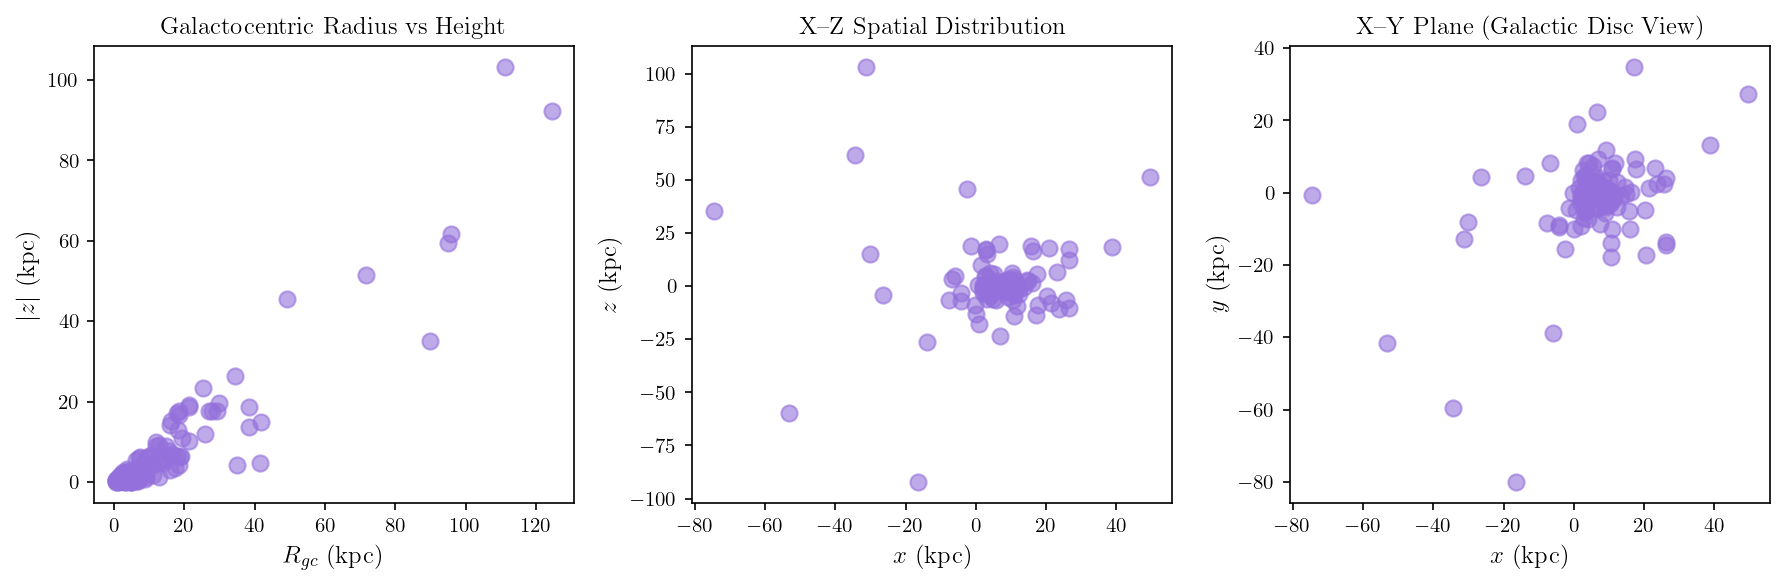

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# R vs |Z|
axes[0].scatter(R, abs(Z), c='mediumpurple', alpha=0.6, s=60)
axes[0].set_xlabel(r"$R_{gc}$ (kpc)", fontsize=12)
axes[0].set_ylabel(r"$|z|$ (kpc)", fontsize=12)
axes[0].set_title("Galactocentric Radius vs Height")

# X vs Z
axes[1].scatter(X, Z, c='mediumpurple', alpha=0.6, s=60)
axes[1].set_xlabel(r"$x$ (kpc)", fontsize=12)
axes[1].set_ylabel(r"$z$ (kpc)", fontsize=12)
axes[1].set_title("X–Z Spatial Distribution")

# X vs Y
axes[2].scatter(X, Y, c='mediumpurple', alpha=0.6, s=60)
axes[2].set_xlabel(r"$x$ (kpc)", fontsize=12)
axes[2].set_ylabel(r"$y$ (kpc)", fontsize=12)
axes[2].set_title("X–Y Plane (Galactic Disc View)")

plt.tight_layout()
plt.show()

### Spatial Mapping with Identification of Accreted Clusters

**Classification scheme:**
- $ |z| > 3 $
- $ R_{gc} > 10 $

Reference: Belokurov, V. & Kravtsov, A. (2024). *"In-situ versus accreted Milky Way globular clusters: a new classification method and implications for cluster formation"*. Monthly Notices of the Royal Astronomical Society, 528(2), 3198–3216. https://doi.org/10.1093/mnras/stad3920

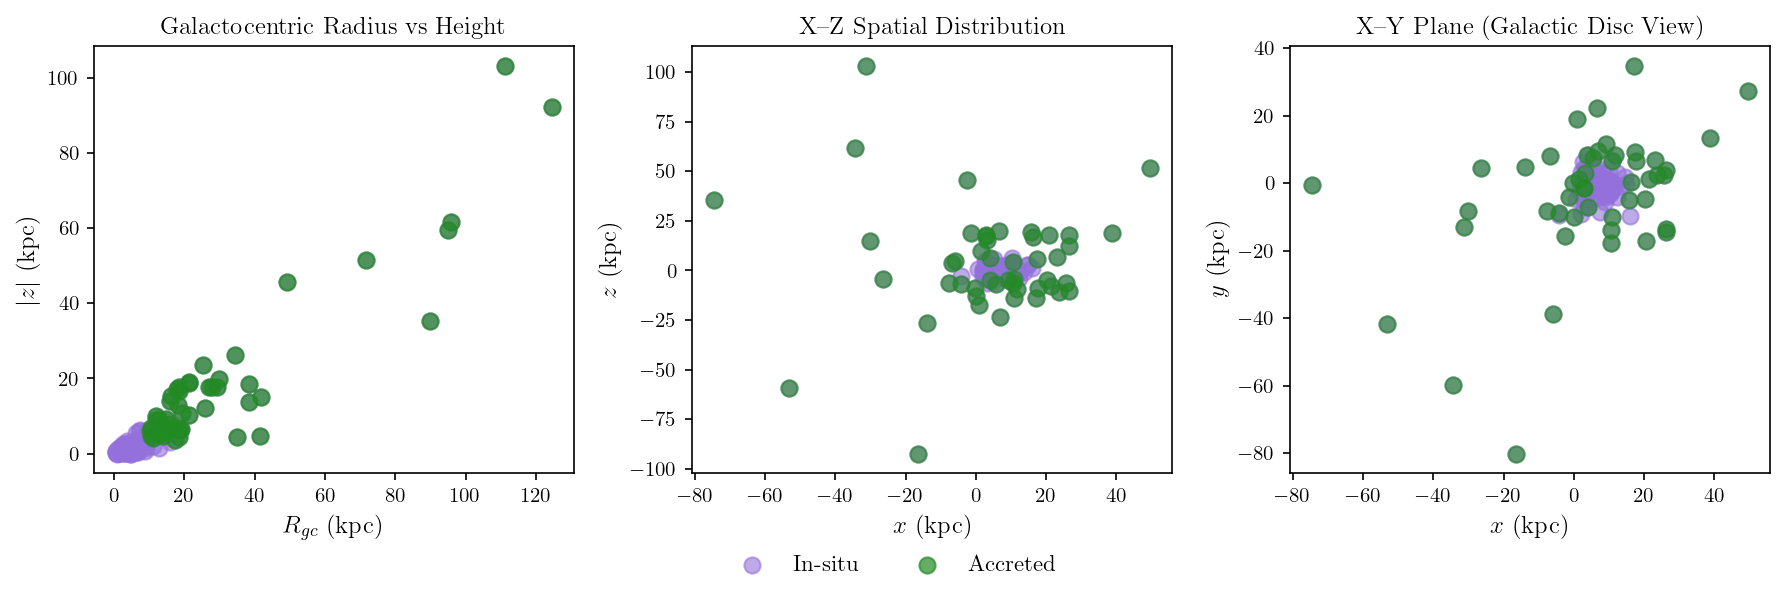

In [10]:
# Identification of accreted clusters
mask = (R > 10) & (abs(Z) > 3)
accreted = harris_p1[mask]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# R vs |Z|
axes[0].scatter(R, abs(Z), c='mediumpurple', alpha=0.6, s=60, label="In-situ")
axes[0].scatter(accreted["R_gc"], abs(accreted["Z"]), c='forestgreen', alpha=0.7, s=60, label="Accreted")
axes[0].set_xlabel(r"$R_{gc}$ (kpc)", fontsize=12)
axes[0].set_ylabel(r"$|z|$ (kpc)", fontsize=12)
axes[0].set_title("Galactocentric Radius vs Height")

# X vs Z
axes[1].scatter(X, Z, c='mediumpurple', alpha=0.6, s=60)
axes[1].scatter(accreted["X"], accreted["Z"], c='forestgreen', alpha=0.6, s=60)
axes[1].set_xlabel(r"$x$ (kpc)", fontsize=12)
axes[1].set_ylabel(r"$z$ (kpc)", fontsize=12)
axes[1].set_title("X–Z Spatial Distribution")

# X vs Y
axes[2].scatter(X, Y, c='mediumpurple', alpha=0.6, s=60)
axes[2].scatter(accreted["X"], accreted["Y"], c='forestgreen', alpha=0.6, s=60)
axes[2].set_xlabel(r"$x$ (kpc)", fontsize=12)
axes[2].set_ylabel(r"$y$ (kpc)", fontsize=12)
axes[2].set_title("X–Y Plane (Galactic Disc View)")

# Shared legend below all plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, frameon=False)

# Adjust layout so legend fits below
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Age-metallicity Relation

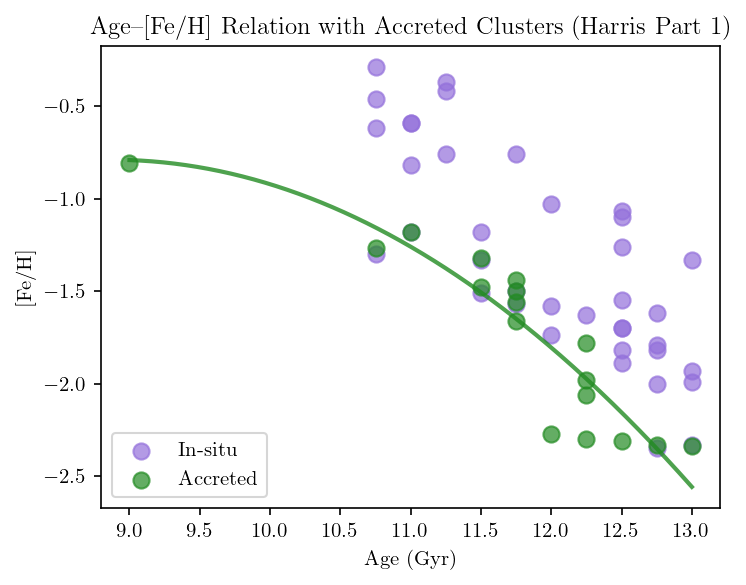

In [14]:
# Identify accreted clusters
mask = (harris_p1["R_gc"] > 10) & (abs(harris_p1["Z"]) > 3)
accreted_names = harris_p1.loc[mask, "Object"]

# Find those names in the VandenBerg dataset
vberg_mask = vandenberg["Object"].isin(accreted_names)

# Separate accreted and in-situ clusters
feh_acc = feh_v[vberg_mask]
ages_acc = ages_v[vberg_mask]
feh_situ = feh_v[~vberg_mask]
ages_situ = ages_v[~vberg_mask]

# Second-order polynomial fits (curved for both)
coeffs_acc = np.polyfit(ages_acc, feh_acc, 2)
a1, b1, c1 = coeffs_acc

# Generate smooth fitted curves
x_fit = np.linspace(min(ages_v), max(ages_v), 300)
y_fit_acc = a1 * x_fit**2 + b1 * x_fit + c1

# Plot
plt.figure(figsize=(5,4))

# Scatter plots
plt.scatter(ages_situ, feh_situ, c='mediumpurple', alpha=0.7, s=60, label="In-situ")
plt.scatter(ages_acc, feh_acc, c='forestgreen', alpha=0.7, s=60, label="Accreted")

# Curved best-fit lines
plt.plot(x_fit, y_fit_acc, color='forestgreen', alpha=0.8, linewidth=2)

plt.title("Age–[Fe/H] Relation with Accreted Clusters (Harris Part 1)")
plt.xlabel("Age (Gyr)")
plt.ylabel("[Fe/H]")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()